<a href="https://colab.research.google.com/github/lgsilva-dev/data-science-fundamentals/blob/main/spotify_fundamentos_ds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentos de Ciência de Dados com Dados do Spotify

**Bem-vindo!** Neste notebook você vai aprender, na prática, os três pilares do Machine Learning supervisionado e não supervisionado usando dados de músicas do Spotify.

---

## O que vamos estudar aqui:

| Módulo | Tipo de Algoritmo | Pergunta que ele responde |
|--------|-------------------|---------------------------|
| 1 | **Classificação** | Esta música é popular ou não? (sim/não) |
| 2 | **Regressão** | Qual será o score de popularidade desta música? (0-100) |
| 3 | **Clusterização** | Quais músicas têm estilo parecido, sem eu dizer o estilo? |

---

## 🎯 Por que dados do Spotify?

O Spotify analisa cada música e extrai **features de áudio** automaticamente:
- Quão dançante é a música?
- Qual a energia?
- É acústica ou eletrônica?
- É animada ou melancólica?

Essas features numéricas são perfeitas para treinar modelos de Machine Learning.

---

> ⚠️ **Nota:** Usaremos um dataset sintético que replica as distribuições reais das features do Spotify. Os dados foram gerados para fins educacionais.

## Passo 0: Bibliotecas

Antes de qualquer coisa, precisamos importar as ferramentas que vamos usar.

- **`pandas`** → manipular tabelas de dados (nosso Excel do Python)
- **`numpy`** → fazer cálculos matemáticos com arrays
- **`matplotlib` / `seaborn`** → criar gráficos
- **`sklearn`** → os modelos de Machine Learning

In [ ]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Garantir resultados reproduzíveis
np.random.seed(42)

✅ Bibliotecas importadas com sucesso!


## Passo 1: Gerando o Dataset Spotify
* Deveria ser Extração de dados ...


Vamos criar nosso dataset com **1.500 músicas** e as principais features que o Spotify usa:

| Feature | O que mede | Range |
|---------|------------|-------|
| `danceability` | Quão dançante é a música | 0.0 → 1.0 |
| `energy` | Intensidade e atividade | 0.0 → 1.0 |
| `loudness` | Volume médio em decibéis | -60 → 0 dB |
| `speechiness` | Quantidade de fala vs. música | 0.0 → 1.0 |
| `acousticness` | Probabilidade de ser acústica | 0.0 → 1.0 |
| `instrumentalness` | Probabilidade de ser instrumental | 0.0 → 1.0 |
| `liveness` | Probabilidade de ser ao vivo | 0.0 → 1.0 |
| `valence` | Positividade emocional da música | 0.0 → 1.0 |
| `tempo` | Batidas por minuto (BPM) | 50 → 200 |
| `duration_ms` | Duração em milissegundos | — |
| `popularity` | Score de popularidade (nosso target) | 0 → 100 |

In [ ]:
# ============================================================
# GERANDO O DATASET SPOTIFY (1.500 músicas)
# ============================================================

n = 1500  # número de músicas

# --- Definindo os gêneros musicais ---
generos = ['Pop', 'Rock', 'Hip-Hop', 'Eletrônica', 'MPB', 'Sertanejo', 'Jazz', 'Clássico']
genero_col = np.random.choice(generos, n, p=[0.25, 0.15, 0.20, 0.15, 0.10, 0.08, 0.04, 0.03])

# --- Features de áudio (com distribuições realistas) ---
danceability     = np.clip(np.random.normal(0.55, 0.18, n), 0, 1)
energy           = np.clip(np.random.normal(0.60, 0.20, n), 0, 1)
loudness         = np.clip(np.random.normal(-8, 5, n), -60, 0)
speechiness      = np.clip(np.random.exponential(0.10, n), 0, 1)
acousticness     = np.clip(np.random.beta(2, 5, n), 0, 1)
instrumentalness = np.clip(np.random.beta(1, 8, n), 0, 1)
liveness         = np.clip(np.random.beta(2, 8, n), 0, 1)
valence          = np.clip(np.random.normal(0.50, 0.22, n), 0, 1)
tempo            = np.clip(np.random.normal(120, 28, n), 50, 210)
duration_ms      = np.clip(np.random.normal(210000, 50000, n), 90000, 480000)

# --- Popularidade: combinação das features + ruído (simula o mundo real) ---
# Músicas dançantes, energéticas e com valência alta tendem a ser mais populares
popularity_raw = (
    35 * danceability +
    20 * energy +
    15 * valence +
    10 * (1 - acousticness) +
    5  * (1 - instrumentalness) +
    np.random.normal(0, 12, n)  # ruído do mundo real
)
popularity = np.clip(popularity_raw, 0, 100).astype(int)

# --- Criando o DataFrame ---
df = pd.DataFrame({
    'genero'          : genero_col,
    'danceability'    : danceability.round(3),
    'energy'          : energy.round(3),
    'loudness'        : loudness.round(2),
    'speechiness'     : speechiness.round(3),
    'acousticness'    : acousticness.round(3),
    'instrumentalness': instrumentalness.round(3),
    'liveness'        : liveness.round(3),
    'valence'         : valence.round(3),
    'tempo'           : tempo.round(1),
    'duration_ms'     : duration_ms.astype(int),
    'popularity'      : popularity
})

print(f'✅ Dataset criado com {df.shape[0]} músicas e {df.shape[1]} colunas!')
print(f'\nPrimeiras 5 linhas:')
df.head()

✅ Dataset criado com 1500 músicas e 12 colunas!

Primeiras 5 linhas:


,genero,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
0,Rock,0.100,0.365,-7.94,0.010,0.277,0.235,0.320,0.223,87.2,204635,33
1,Jazz,0.962,0.421,-5.60,0.065,0.105,0.026,0.029,0.557,127.1,212179,66
2,Eletrônica,0.300,0.719,-9.34,0.479,0.464,0.178,0.154,0.686,51.2,235976,70
3,Hip-Hop,0.254,0.410,-17.18,0.147,0.199,0.024,0.256,0.499,131.6,196782,27
4,Pop,0.734,0.693,-10.16,0.024,0.640,0.069,0.144,0.146,80.5,235820,33


## Passo 2: Análise Exploratória dos Dados (EDA)

Antes de treinar qualquer modelo, precisamos **entender nossos dados**. Isso se chama **EDA** (Exploratory Data Analysis) e é uma das etapas mais importantes da ciência de dados.

> 💡 **DISCLAIMER:** Nunca treine um modelo sem antes explorar os dados. Você pode descobrir erros, outliers e padrões que mudam completamente sua abordagem.

In [ ]:
# Informações básicas do dataset
print('=== INFORMAÇÕES DO DATASET ===')
print(f'Linhas (músicas): {df.shape[0]}')
print(f'Colunas (features): {df.shape[1]}')
print()
print('--- Tipos de dados ---')
print(df.dtypes)
print()
print('--- Valores ausentes (NaN) ---')
print(df.isnull().sum())

=== INFORMAÇÕES DO DATASET ===
Linhas (músicas): 1500
Colunas (features): 12

--- Tipos de dados ---
genero               object
danceability        float64
energy              float64
loudness            float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
popularity            int64
dtype: object

--- Valores ausentes (NaN) ---
genero              0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
popularity          0
dtype: int64


In [ ]:
# Estatísticas descritivas
print('=== ESTATÍSTICAS DESCRITIVAS ===')
df.describe().round(2)

=== ESTATÍSTICAS DESCRITIVAS ===


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,popularity
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,0.56,0.60,-8.28,0.09,0.28,0.12,0.19,0.50,119.83,210856.60,49.75
std,0.18,0.20,4.73,0.09,0.16,0.10,0.12,0.21,26.91,48252.03,14.61
min,0.01,0.00,-23.88,0.00,0.01,0.00,0.01,0.00,50.00,90000.00,0.00
25%,0.43,0.46,-11.34,0.03,0.16,0.04,0.10,0.34,100.98,178245.25,40.00
50%,0.55,0.59,-8.10,0.06,0.26,0.09,0.17,0.49,120.75,210339.00,50.00
75%,0.67,0.73,-4.73,0.12,0.38,0.17,0.26,0.64,138.10,242598.75,60.00
max,1.00,1.00,0.00,0.68,0.82,0.54,0.65,1.00,207.80,370768.00,100.00


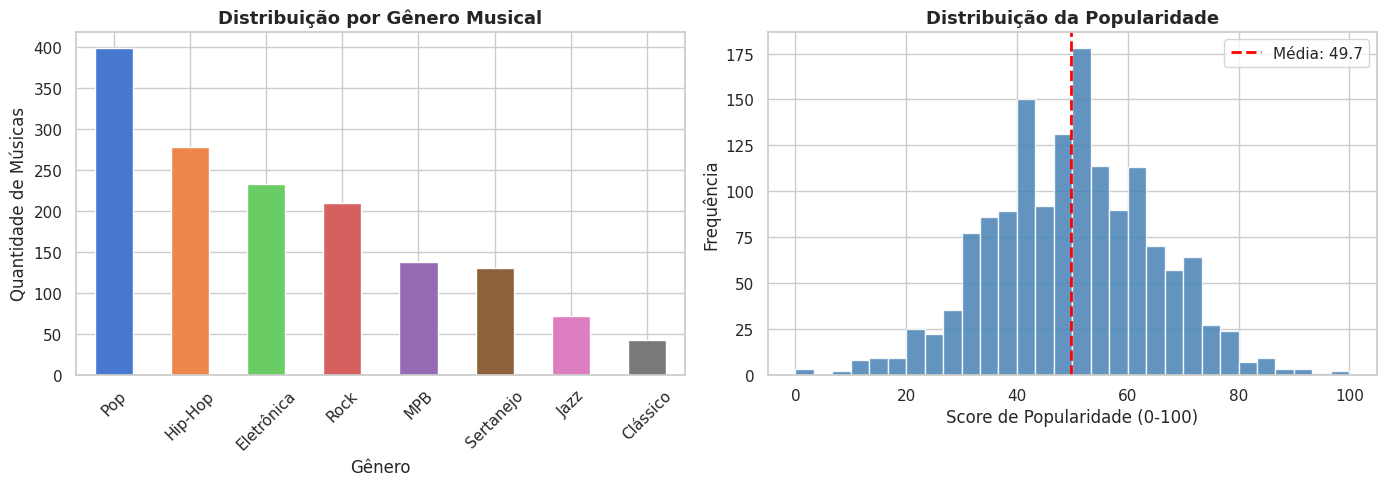

In [ ]:
# Distribuição de gêneros musicais
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contagem_generos = df['genero'].value_counts()
contagem_generos.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(contagem_generos)))
axes[0].set_title('Distribuição por Gênero Musical', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gênero')
axes[0].set_ylabel('Quantidade de Músicas')
axes[0].tick_params(axis='x', rotation=45)

# Distribuição da popularidade
axes[1].hist(df['popularity'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(df['popularity'].mean(), color='red', linestyle='--', linewidth=2, label=f"Média: {df['popularity'].mean():.1f}")
axes[1].set_title('Distribuição da Popularidade', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Score de Popularidade (0-100)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_3774/1788266925.py:13: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


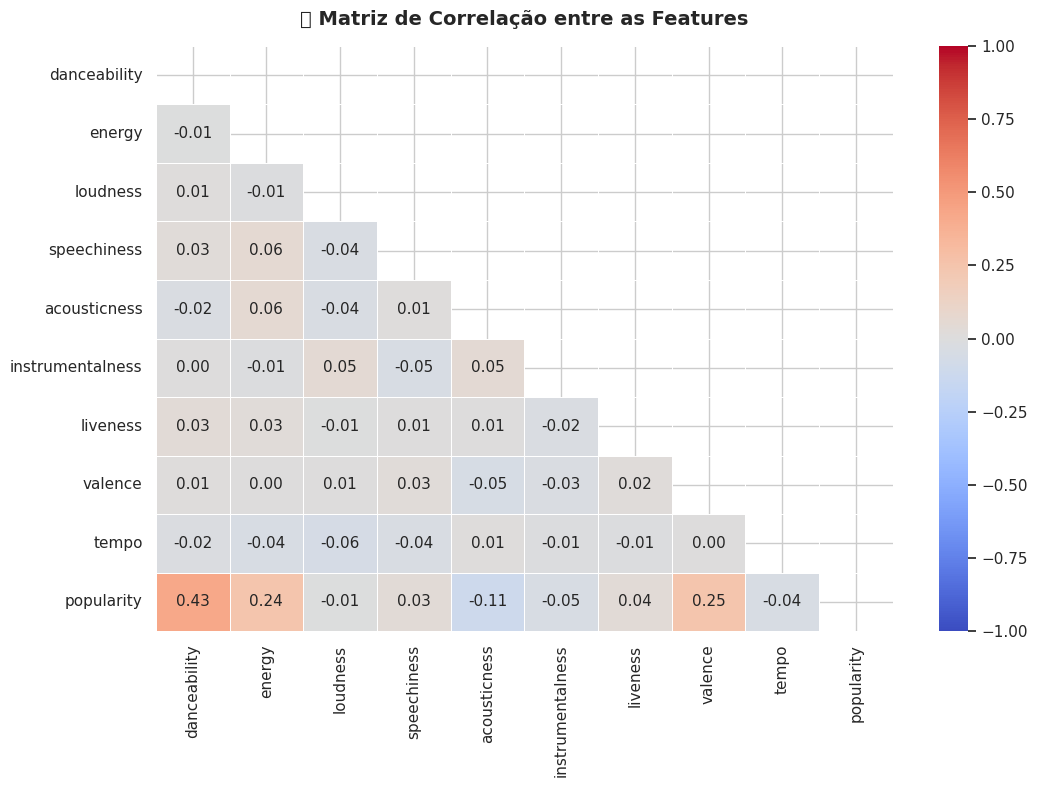


💡 COMO LER ESTE GRÁFICO:
  +1.0 = correlação positiva perfeita (uma sobe, a outra sobe)
  -1.0 = correlação negativa perfeita (uma sobe, a outra desce)
   0.0 = sem relação linear entre as duas features


In [ ]:
# Matriz de correlação — quais features se relacionam entre si?
features_numericas = ['danceability', 'energy', 'loudness', 'speechiness',
                      'acousticness', 'instrumentalness', 'liveness',
                      'valence', 'tempo', 'popularity']

correlacao = df[features_numericas].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(correlacao, dtype=bool))  # mostrar só metade
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('🔗 Matriz de Correlação entre as Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print()
print('💡 COMO LER ESTE GRÁFICO:')
print('  +1.0 = correlação positiva perfeita (uma sobe, a outra sobe)')
print('  -1.0 = correlação negativa perfeita (uma sobe, a outra desce)')
print('   0.0 = sem relação linear entre as duas features')

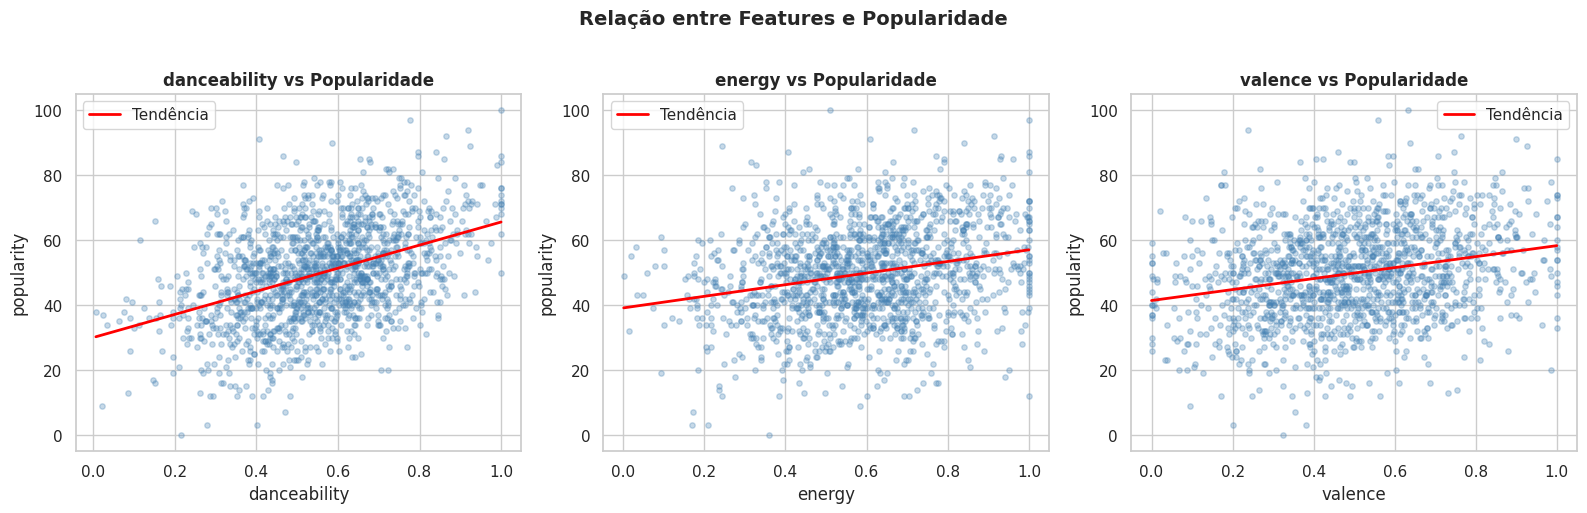

In [ ]:
# Scatterplots: como danceability e energy se relacionam com a popularidade?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pares = [
    ('danceability', 'danceability vs Popularidade'),
    ('energy',       'energy vs Popularidade'),
    ('valence',      'valence vs Popularidade'),
]

for ax, (feature, titulo) in zip(axes, pares):
    ax.scatter(df[feature], df['popularity'], alpha=0.3, s=15, color='steelblue')
    # linha de tendência
    z = np.polyfit(df[feature], df['popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Tendência')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('popularity')
    ax.legend()

plt.suptitle('Relação entre Features e Popularidade', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## Passo 3: Feature Selection — A Decisão mais Importante do ML

**Feature Selection** (seleção de features) é o processo de escolher **quais colunas do dataset** vão entrar no modelo de Machine Learning.

### Por que isso é tão importante?

Imagine que você quer prever se uma música será popular. Você tem acesso a:
- ✅ `danceability` — faz sentido, músicas dançantes tendem a ser mais ouvidas
- ✅ `energy` — faz sentido, músicas energéticas são mais populares em playlists
- ❓ `duration_ms` — talvez ajude, mas músicas muito longas tendem a ter menos plays
- ❌ `liveness` — pouco impacto na popularidade em geral

### Os 3 critérios para escolher uma feature:

| Critério | Pergunta | Exemplo |
|----------|----------|---------|
| **Relevância** | Essa feature tem relação com o que quero prever? | `danceability` tem correlação com popularidade |
| **Disponibilidade** | Essa feature estará disponível quando fizer previsões futuras? | Se só existe no histórico, não serve |
| **Redundância** | Essa feature diz a mesma coisa que outra? | `energy` e `loudness` são muito correlacionadas |

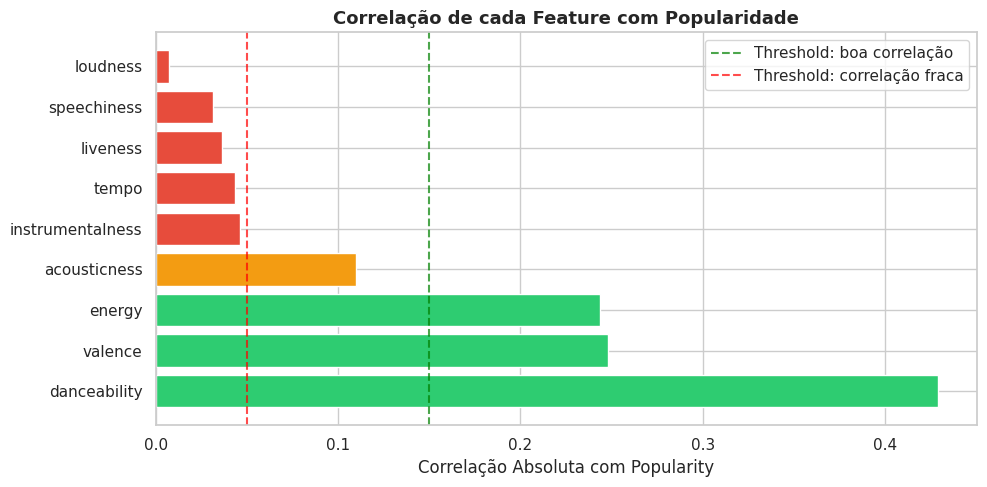


🟢 FEATURES MAIS RELEVANTES (usar no modelo):
   danceability: 0.429
   valence: 0.248
   energy: 0.244

🟡 FEATURES MEDIANAS (analisar caso a caso):
   acousticness: 0.110

🔴 FEATURES POUCO RELEVANTES (candidatas a remover):
   instrumentalness: 0.046
   tempo: 0.043
   liveness: 0.036
   speechiness: 0.031
   loudness: 0.007


In [ ]:
# Analisando a correlação de cada feature com a popularidade
correlacao_com_popularidade = df[features_numericas].corr()['popularity'].drop('popularity').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.barh(correlacao_com_popularidade.index, correlacao_com_popularidade.values,
                color=['#2ecc71' if v > 0.15 else '#e74c3c' if v < 0.05 else '#f39c12'
                       for v in correlacao_com_popularidade.values])
plt.axvline(0.15, color='green', linestyle='--', alpha=0.7, label='Threshold: boa correlação')
plt.axvline(0.05, color='red', linestyle='--', alpha=0.7, label='Threshold: correlação fraca')
plt.title('Correlação de cada Feature com Popularidade', fontsize=13, fontweight='bold')
plt.xlabel('Correlação Absoluta com Popularity')
plt.legend()
plt.tight_layout()
plt.show()

print('\n🟢 FEATURES MAIS RELEVANTES (usar no modelo):')
boas = correlacao_com_popularidade[correlacao_com_popularidade > 0.15]
for f, v in boas.items():
    print(f'   {f}: {v:.3f}')

print('\n🟡 FEATURES MEDIANAS (analisar caso a caso):')
medias = correlacao_com_popularidade[(correlacao_com_popularidade >= 0.05) & (correlacao_com_popularidade <= 0.15)]
for f, v in medias.items():
    print(f'   {f}: {v:.3f}')

print('\n🔴 FEATURES POUCO RELEVANTES (candidatas a remover):')
fracas = correlacao_com_popularidade[correlacao_com_popularidade < 0.05]
for f, v in fracas.items():
    print(f'   {f}: {v:.3f}')

In [ ]:
# ============================================================
# DECISÃO FINAL: Quais features usar nos modelos
# ============================================================

# Features escolhidas e o PORQUÊ de cada uma:
features_selecionadas = [
    'danceability',     # Alta correlação com popularidade
    'energy',           # Alta correlação com popularidade
    'valence',          # Músicas positivas tendem a ser mais tocadas
    'loudness',         # Proxy de energia / produção
    'acousticness',     # Diferencia estilos (acústico vs. produzido)
    'tempo',            # BPM influencia o estilo da música
    'speechiness',      # Diferencia hip-hop de instrumentais
    'instrumentalness', # Diferencia música com letra de instrumental
]

# Features EXCLUÍDAS e o PORQUÊ:
features_excluidas = {
    'liveness': 'Correlação muito fraca com popularidade',
    'duration_ms': 'Pouca relação com popularidade; pode causar ruído',
}

print('✅ Features que entrarão nos modelos:')
for f in features_selecionadas:
    print(f'   ✔ {f}')

print('\n❌ Features excluídas:')
for f, motivo in features_excluidas.items():
    print(f'   ✘ {f}: {motivo}')

# Separando X (features de entrada) e y (target de saída)
X = df[features_selecionadas].copy()
y_regressao      = df['popularity'].copy()           # para Regressão (valor contínuo)
y_classificacao  = (df['popularity'] >= 60).astype(int)  # para Classificação (0 ou 1)

print(f'\n📊 Shape de X (entradas): {X.shape}')
print(f'📊 Shape de y_regressao: {y_regressao.shape}')
print(f'📊 Shape de y_classificacao: {y_classificacao.shape}')
print(f'\n🏷️ Distribuição das classes (Classificação):')
print(f'   Popular (1):     {y_classificacao.sum()} músicas ({y_classificacao.mean()*100:.1f}%)')
print(f'   Não popular (0): {(y_classificacao == 0).sum()} músicas ({(1-y_classificacao.mean())*100:.1f}%)')

✅ Features que entrarão nos modelos:
   ✔ danceability
   ✔ energy
   ✔ valence
   ✔ loudness
   ✔ acousticness
   ✔ tempo
   ✔ speechiness
   ✔ instrumentalness

❌ Features excluídas:
   ✘ liveness: Correlação muito fraca com popularidade
   ✘ duration_ms: Pouca relação com popularidade; pode causar ruído

📊 Shape de X (entradas): (1500, 8)
📊 Shape de y_regressao: (1500,)
📊 Shape de y_classificacao: (1500,)

🏷️ Distribuição das classes (Classificação):
   Popular (1):     380 músicas (25.3%)
   Não popular (0): 1120 músicas (74.7%)


---

## 🗂️ MÓDULO 1: Classificação

### O que é Classificação?

Classificação é quando queremos **prever uma categoria** — a resposta é sempre um grupo, não um número contínuo.

**Exemplos reais:**
- E-mail: spam ou não spam?
- Diagnóstico: tumor maligno ou benigno?
- Spotify: música popular ou não popular?

### Algoritmo: Random Forest Classifier

O **Random Forest** é como fazer uma votação entre 100 "especialistas" (árvores de decisão). Cada especialista analisa as features de forma diferente e vota. A classe com mais votos vence.

```
Árvore 1: danceability > 0.7? → Popular
Árvore 2: energy > 0.8 e valence > 0.6? → Popular  
Árvore 3: acousticness < 0.2? → Não popular
...
Votação final: 70 votos Popular → Resultado: POPULAR ✅
```

### Etapas do Pipeline:
1. Dividir os dados em treino e teste
2. Normalizar as features
3. Treinar o modelo
4. Avaliar o desempenho

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, RocCurveDisplay)

# ============================================================
# ETAPA 1: Dividir em treino e teste
# ============================================================
# Por que dividir? Para testar o modelo em dados que ele NUNCA viu.
# Usar 80% para treinar e 20% para testar.

X_train, X_test, y_train, y_test = train_test_split(
    X, y_classificacao,
    test_size=0.2,    # 20% para teste
    random_state=42,  # semente para reprodutibilidade
    stratify=y_classificacao  # manter proporção de classes nos dois conjuntos
)

print('=== DIVISÃO TREINO / TESTE ===')
print(f'Treino: {X_train.shape[0]} músicas ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:  {X_test.shape[0]} músicas  ({X_test.shape[0]/len(X)*100:.0f}%)')

=== DIVISÃO TREINO / TESTE ===
Treino: 1200 músicas (80%)
Teste:  300 músicas  (20%)


In [ ]:
# ============================================================
# ETAPA 2: Normalização (StandardScaler)
# ============================================================
# Por que normalizar?
# - tempo está em BPM (50-200)
# - danceability está entre 0 e 1
# Se não normalizarmos, o modelo pode dar mais peso ao tempo só por ter valores maiores!
# StandardScaler transforma cada feature para ter média=0 e desvio padrão=1.

scaler_clf = StandardScaler()

# IMPORTANTE: fit apenas no treino, transform em ambos
# Motivo: não queremos que o teste "vaze" informações para o treino
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled  = scaler_clf.transform(X_test)  # só transform, sem fit!

print('Antes da normalização (primeiros 3 valores de tempo e danceability):')
print(f'  tempo:        {X_train["tempo"].values[:3]}')
print(f'  danceability: {X_train["danceability"].values[:3]}')

idx_tempo = features_selecionadas.index('tempo')
idx_dance = features_selecionadas.index('danceability')
print('\nDepois da normalização:')
print(f'  tempo:        {X_train_scaled[:3, idx_tempo].round(2)}')
print(f'  danceability: {X_train_scaled[:3, idx_dance].round(2)}')
print('\n✅ Agora as escalas são comparáveis!')

Antes da normalização (primeiros 3 valores de tempo e danceability):
  tempo:        [146.2 103.6 136.6]
  danceability: [0.575 0.414 0.439]

Depois da normalização:
  tempo:        [ 0.97 -0.6   0.62]
  danceability: [ 0.12 -0.8  -0.66]

✅ Agora as escalas são comparáveis!


In [ ]:
# ============================================================
# ETAPA 3: Treinar o modelo
# ============================================================

clf = RandomForestClassifier(
    n_estimators=100,  # 100 árvores de decisão
    max_depth=8,       # profundidade máxima de cada árvore
    random_state=42
)

clf.fit(X_train_scaled, y_train)

print('✅ Modelo treinado!')
print(f'   Árvores na floresta: {clf.n_estimators}')
print(f'   Features usadas: {len(features_selecionadas)}')

✅ Modelo treinado!
   Árvores na floresta: 100
   Features usadas: 8


In [ ]:
# ============================================================
# ETAPA 4: Avaliar o modelo
# ============================================================

y_pred_clf  = clf.predict(X_test_scaled)
y_prob_clf  = clf.predict_proba(X_test_scaled)[:, 1]  # probabilidade da classe 1

acuracia = accuracy_score(y_test, y_pred_clf)
auc      = roc_auc_score(y_test, y_prob_clf)

print('=== MÉTRICAS DE CLASSIFICAÇÃO ===')
print(f'Acurácia: {acuracia:.2%}')
print(f'AUC-ROC:  {auc:.3f}')
print()
print(classification_report(y_test, y_pred_clf, target_names=['Não Popular', 'Popular']))

=== MÉTRICAS DE CLASSIFICAÇÃO ===
Acurácia: 75.67%
AUC-ROC:  0.765

              precision    recall  f1-score   support

 Não Popular       0.77      0.96      0.85       224
     Popular       0.57      0.17      0.26        76

    accuracy                           0.76       300
   macro avg       0.67      0.56      0.56       300
weighted avg       0.72      0.76      0.70       300



/tmp/ipykernel_3774/2742041445.py:26: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


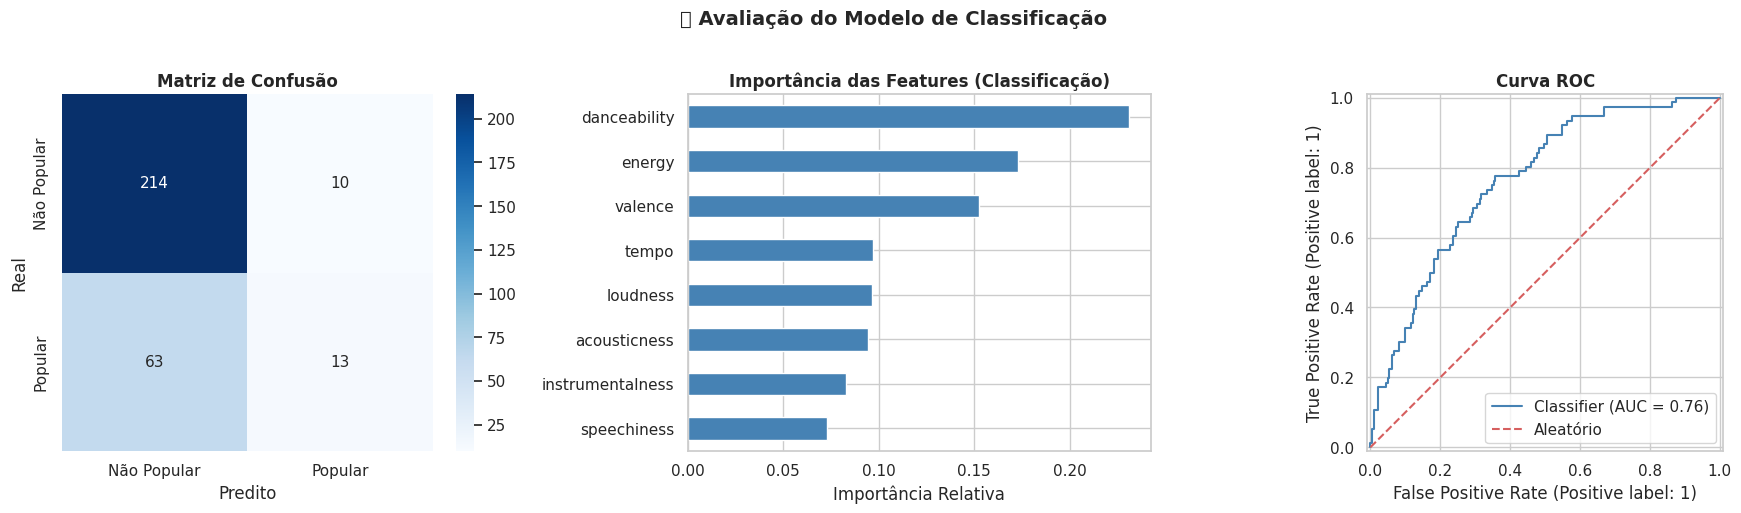


💡 COMO INTERPRETAR:
  Matriz de Confusão: diagonal principal = acertos | fora da diagonal = erros
  Importância das Features: quais features mais influenciaram as decisões
  Curva ROC: quanto mais próxima do canto superior esquerdo, melhor o modelo
  AUC = 0.765 → um classificador aleatório teria AUC = 0.5


In [ ]:
# Visualizações: Matriz de Confusão + Importância das Features + ROC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Matriz de Confusão --
cm = confusion_matrix(y_test, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Não Popular', 'Popular'],
            yticklabels=['Não Popular', 'Popular'])
axes[0].set_title('Matriz de Confusão', fontweight='bold')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# -- Importância das Features --
importancias = pd.Series(clf.feature_importances_, index=features_selecionadas).sort_values()
importancias.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Importância das Features (Classificação)', fontweight='bold')
axes[1].set_xlabel('Importância Relativa')

# -- Curva ROC --
RocCurveDisplay.from_predictions(y_test, y_prob_clf, ax=axes[2], color='steelblue')
axes[2].plot([0,1], [0,1], 'r--', label='Aleatório')
axes[2].set_title('Curva ROC', fontweight='bold')
axes[2].legend()

plt.suptitle('📊 Avaliação do Modelo de Classificação', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n💡 COMO INTERPRETAR:')
print('  Matriz de Confusão: diagonal principal = acertos | fora da diagonal = erros')
print('  Importância das Features: quais features mais influenciaram as decisões')
print('  Curva ROC: quanto mais próxima do canto superior esquerdo, melhor o modelo')
print(f'  AUC = {auc:.3f} → um classificador aleatório teria AUC = 0.5')

---

## 📈 MÓDULO 2: Regressão

### O que é Regressão?

Regressão é quando queremos **prever um número contínuo** — não uma categoria, mas um valor.

**Comparação com Classificação:**

| | Classificação | Regressão |
|--|--------------|----------|
| **Pergunta** | Esta música É popular? | Qual o score de popularidade? |
| **Resposta** | Sim / Não | 73.4 |
| **Exemplos** | Spam, Diagnóstico, Fraude | Preço de imóvel, Temperatura, Nota |

### Algoritmo: Random Forest Regressor

Similar ao Classifier, mas ao invés de votar em categorias, **cada árvore prediz um número** e o resultado final é a **média** das predições.

### Métricas de avaliação:
- **MAE** (Mean Absolute Error): erro médio em pontos de popularidade
- **RMSE** (Root Mean Squared Error): penaliza mais os erros grandes
- **R²** (R-squared): % da variância explicada pelo modelo (0 = inútil, 1 = perfeito)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# Pipeline de Regressão
# ============================================================

# Etapa 1: Divisão treino/teste (agora com y de regressão)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_regressao,
    test_size=0.2,
    random_state=42
)

# Etapa 2: Normalização
scaler_reg = StandardScaler()
X_train_r_sc = scaler_reg.fit_transform(X_train_r)
X_test_r_sc  = scaler_reg.transform(X_test_r)

# Etapa 3: Treinar o modelo
reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)
reg.fit(X_train_r_sc, y_train_r)

# Etapa 4: Previsões
y_pred_reg = reg.predict(X_test_r_sc)

# Etapa 5: Métricas
mae  = mean_absolute_error(y_test_r, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_reg))
r2   = r2_score(y_test_r, y_pred_reg)

print('=== MÉTRICAS DE REGRESSÃO ===')
print(f'MAE  (Erro Médio Absoluto): {mae:.2f} pontos de popularidade')
print(f'RMSE (Raiz do Erro Quadrático): {rmse:.2f}')
print(f'R²   (Variância Explicada): {r2:.3f}')
print(f'\nInterpretação: o modelo erra em média {mae:.1f} pontos no score de popularidade (0-100)')

=== MÉTRICAS DE REGRESSÃO ===
MAE  (Erro Médio Absoluto): 10.73 pontos de popularidade
RMSE (Raiz do Erro Quadrático): 13.14
R²   (Variância Explicada): 0.197

Interpretação: o modelo erra em média 10.7 pontos no score de popularidade (0-100)


/tmp/ipykernel_3774/488062131.py:30: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


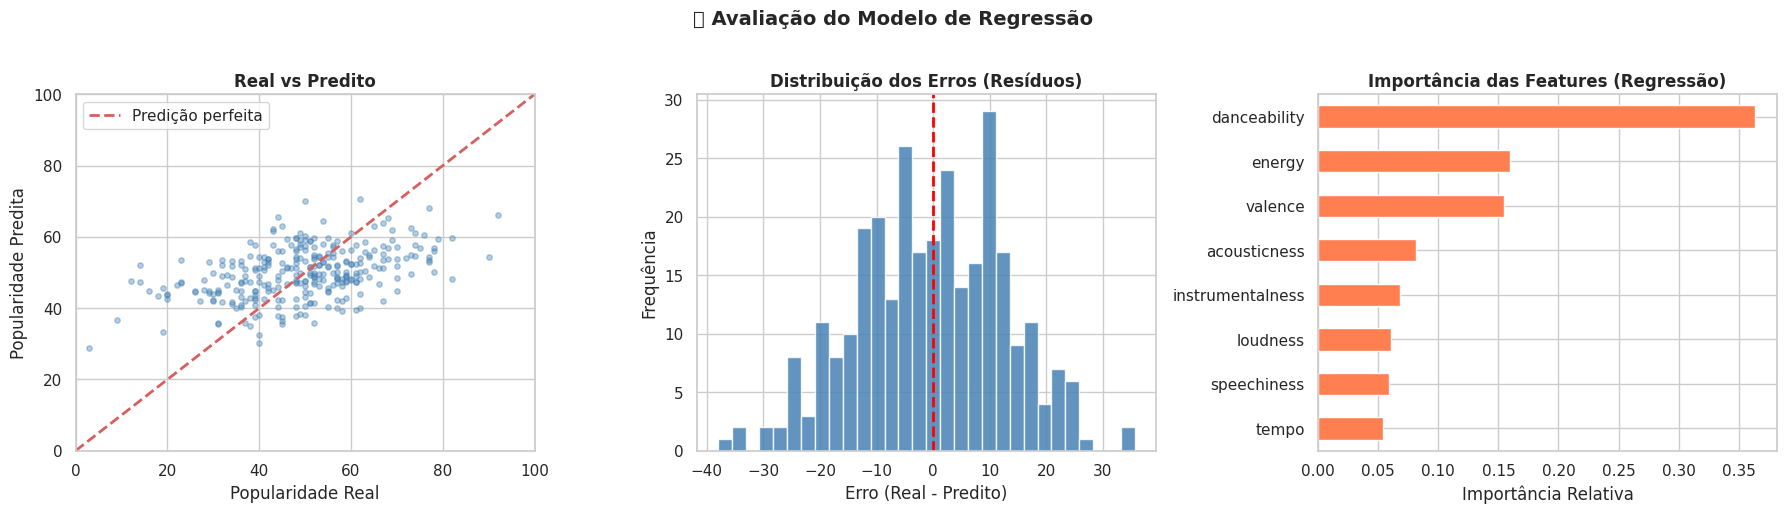


💡 COMO INTERPRETAR:
  Real vs Predito: pontos próximos da linha vermelha = boas predições
  Resíduos: devem ser centrados em 0 e distribuídos simetricamente
  R² = 0.197 → o modelo explica 19.7% da variação na popularidade


In [ ]:
# Visualizações de Regressão
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Predito vs Real --
axes[0].scatter(y_test_r, y_pred_reg, alpha=0.4, s=15, color='steelblue')
lim = [0, 100]
axes[0].plot(lim, lim, 'r--', linewidth=2, label='Predição perfeita')
axes[0].set_xlabel('Popularidade Real')
axes[0].set_ylabel('Popularidade Predita')
axes[0].set_title('Real vs Predito', fontweight='bold')
axes[0].legend()
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)

# -- Distribuição dos erros (resíduos) --
residuos = y_test_r - y_pred_reg
axes[1].hist(residuos, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Erro (Real - Predito)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Erros (Resíduos)', fontweight='bold')

# -- Importância das Features na Regressão --
importancias_reg = pd.Series(reg.feature_importances_, index=features_selecionadas).sort_values()
importancias_reg.plot(kind='barh', ax=axes[2], color='coral')
axes[2].set_title('Importância das Features (Regressão)', fontweight='bold')
axes[2].set_xlabel('Importância Relativa')

plt.suptitle('📊 Avaliação do Modelo de Regressão', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n💡 COMO INTERPRETAR:')
print('  Real vs Predito: pontos próximos da linha vermelha = boas predições')
print('  Resíduos: devem ser centrados em 0 e distribuídos simetricamente')
print(f'  R² = {r2:.3f} → o modelo explica {r2*100:.1f}% da variação na popularidade')

---

## 🔵 MÓDULO 3: Clusterização

### O que é Clusterização?

Clusterização é **aprendizado não supervisionado** — não temos labels (respostas certas). O algoritmo descobre sozinho grupos naturais nos dados.

**Por que usar?**
> Imagine que você quer organizar uma biblioteca musical mas não sabe quantos gêneros existem. A clusterização encontra os grupos automaticamente, sem você precisar dizer o que é Rock ou Pop.

**Diferença fundamental:**

| | Supervisionado (Classificação/Regressão) | Não Supervisionado (Clusterização) |
|--|------------------------------------------|------------------------------------|
| **Dados de treino** | Tem labels (resposta certa) | Sem labels |
| **Objetivo** | Aprender com exemplos | Descobrir estrutura oculta |
| **Aplicações** | Spam, diagnóstico, preço | Segmentação, recomendação, anomalias |

### Algoritmo: K-Means

K-Means divide os dados em **K grupos** (clusters) minimizando a distância de cada ponto ao centro do seu grupo.

**Como funciona:**
1. Escolhe K centros aleatórios
2. Cada música vai para o cluster do centro mais próximo
3. Os centros se movem para o centro de gravidade do cluster
4. Repete até estabilizar

### Como escolher K? O Método do Cotovelo (Elbow Method)

/tmp/ipykernel_3774/2874033278.py:30: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


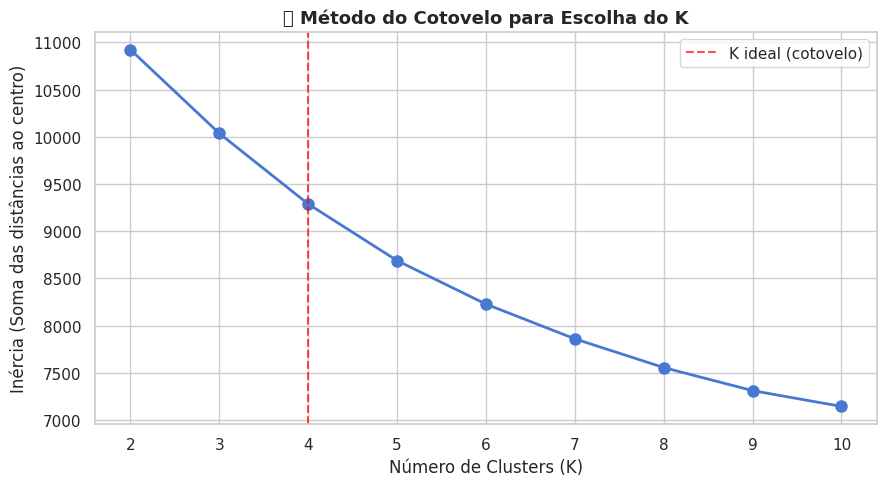

💡 O "cotovelo" indica onde adicionar mais clusters não traz ganho significativo.
   Escolheremos K=4 clusters.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Normalizar os dados para clusterização
scaler_clust = StandardScaler()
X_scaled_clust = scaler_clust.fit_transform(X)

# ============================================================
# MÉTODO DO COTOVELO: encontrar o K ideal
# ============================================================
# Testamos K de 2 a 10 e medimos a "inércia" (soma das distâncias ao centro)
# O K ideal fica no "cotovelo" da curva

inercias = []
ks = range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_clust)
    inercias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(ks, inercias, 'bo-', markersize=8, linewidth=2)
plt.axvline(4, color='red', linestyle='--', alpha=0.7, label='K ideal (cotovelo)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Soma das distâncias ao centro)')
plt.title('🔍 Método do Cotovelo para Escolha do K', fontweight='bold', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print('💡 O "cotovelo" indica onde adicionar mais clusters não traz ganho significativo.')
print('   Escolheremos K=4 clusters.')

In [ ]:
# ============================================================
# Treinando o K-Means com K=4
# ============================================================

K_IDEAL = 4
kmeans = KMeans(n_clusters=K_IDEAL, random_state=42, n_init=10)
kmeans.fit(X_scaled_clust)

# Adicionando o cluster ao dataframe
df['cluster'] = kmeans.labels_

print(f'✅ K-Means treinado com K={K_IDEAL}')
print(f'\nDistribuição das músicas por cluster:')
print(df['cluster'].value_counts().sort_index())

✅ K-Means treinado com K=4

Distribuição das músicas por cluster:
cluster
0    262
1    517
2    202
3    519
Name: count, dtype: int64


/tmp/ipykernel_3774/4090284227.py:44: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


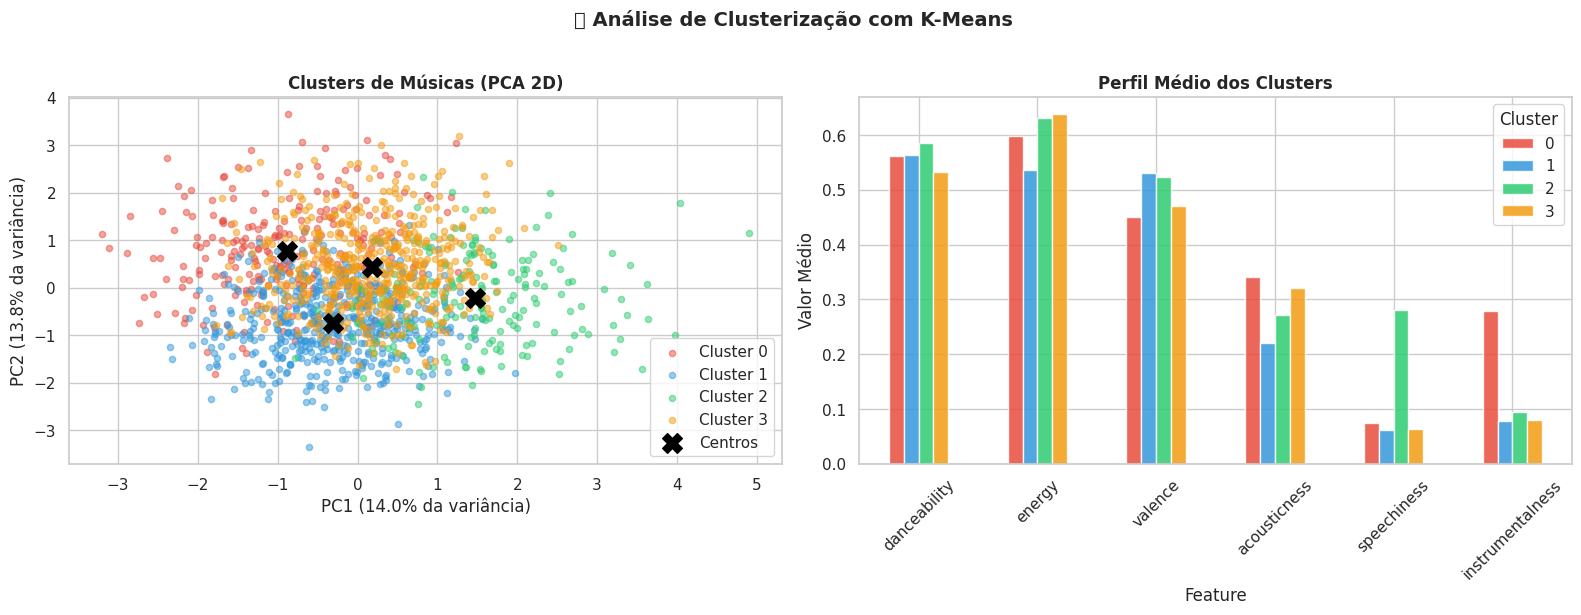

In [ ]:
# Visualizando os clusters com PCA (redução para 2D)
# PCA reduz as 8 features para 2 dimensões, preservando a maior variância possível
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled_clust)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cores_cluster = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
nomes_cluster = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

# -- Scatter por cluster --
for cluster_id in range(K_IDEAL):
    mask = df['cluster'] == cluster_id
    axes[0].scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=cores_cluster[cluster_id],
        label=nomes_cluster[cluster_id],
        alpha=0.5, s=20
    )

# Centros dos clusters
centros_2d = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centros_2d[:, 0], centros_2d[:, 1],
                c='black', marker='X', s=200, label='Centros', zorder=5)
axes[0].set_title('Clusters de Músicas (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)')
axes[0].legend()

# -- Perfil médio dos clusters (radar/bar) --
features_plot = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'instrumentalness']
perfil_clusters = df.groupby('cluster')[features_plot].mean()

perfil_clusters.T.plot(kind='bar', ax=axes[1],
                       color=cores_cluster,
                       alpha=0.85, edgecolor='white')
axes[1].set_title('Perfil Médio dos Clusters', fontweight='bold')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Valor Médio')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Cluster')

plt.suptitle('🔵 Análise de Clusterização com K-Means', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Interpretando os clusters: quem são essas músicas?
print('=== PERFIL DOS CLUSTERS ===')
print()

perfil = df.groupby('cluster')[features_plot + ['popularity']].mean().round(3)

descricoes = [
    '🎤 Músicas energéticas e dançantes (Pop/Hip-Hop)',
    '🎸 Alta energia, baixa dançabilidade (Rock)',
    '🎸 Acústicas e introspectivas (MPB/Folk)',
    '🎹 Instrumentais ou com pouca letra'
]

for cluster_id in range(K_IDEAL):
    print(f'--- Cluster {cluster_id}: {descricoes[cluster_id]} ---')
    row = perfil.loc[cluster_id]
    print(f'  danceability:     {row["danceability"]:.3f}')
    print(f'  energy:           {row["energy"]:.3f}')
    print(f'  valence:          {row["valence"]:.3f}')
    print(f'  acousticness:     {row["acousticness"]:.3f}')
    print(f'  speechiness:      {row["speechiness"]:.3f}')
    print(f'  instrumentalness: {row["instrumentalness"]:.3f}')
    print(f'  popularidade avg: {row["popularity"]:.1f}')
    n_cluster = (df['cluster'] == cluster_id).sum()
    print(f'  músicas:          {n_cluster}')
    print()

=== PERFIL DOS CLUSTERS ===

--- Cluster 0: 🎤 Músicas energéticas e dançantes (Pop/Hip-Hop) ---
  danceability:     0.562
  energy:           0.598
  valence:          0.450
  acousticness:     0.342
  speechiness:      0.074
  instrumentalness: 0.279
  popularidade avg: 47.5
  músicas:          262

--- Cluster 1: 🎸 Alta energia, baixa dançabilidade (Rock) ---
  danceability:     0.563
  energy:           0.537
  valence:          0.530
  acousticness:     0.221
  speechiness:      0.062
  instrumentalness: 0.078
  popularidade avg: 50.0
  músicas:          517

--- Cluster 2: 🎸 Acústicas e introspectivas (MPB/Folk) ---
  danceability:     0.585
  energy:           0.632
  valence:          0.524
  acousticness:     0.271
  speechiness:      0.281
  instrumentalness: 0.094
  popularidade avg: 52.2
  músicas:          202

--- Cluster 3: 🎹 Instrumentais ou com pouca letra ---
  danceability:     0.532
  energy:           0.638
  valence:          0.471
  acousticness:     0.320
  speec

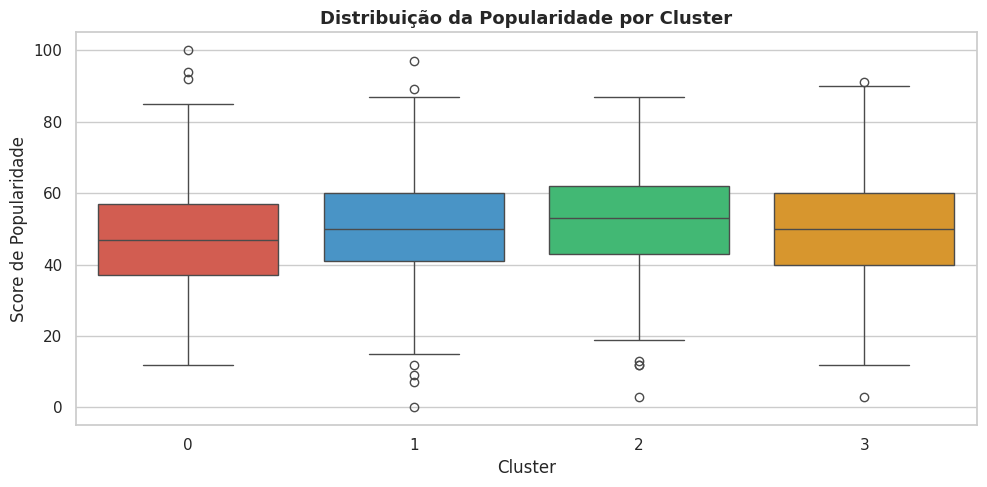


💡 Este gráfico nos mostra se um determinado estilo musical
   (representado pelo cluster) tende a ser mais ou menos popular.


In [ ]:
# Popularidade por cluster
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='cluster', y='popularity',
            palette=cores_cluster, hue='cluster', legend=False)
plt.title('Distribuição da Popularidade por Cluster', fontweight='bold', fontsize=13)
plt.xlabel('Cluster')
plt.ylabel('Score de Popularidade')
plt.tight_layout()
plt.show()

print('\n💡 Este gráfico nos mostra se um determinado estilo musical')
print('   (representado pelo cluster) tende a ser mais ou menos popular.')

---

## 🎓 Conclusão: O que você aprendeu?

### Resumo dos 3 algoritmos

| Algoritmo | Tipo | Quando usar | Saída |
|-----------|------|-------------|-------|
| **Random Forest Classifier** | Supervisionado | Quando a resposta é uma categoria | Popular / Não Popular |
| **Random Forest Regressor** | Supervisionado | Quando a resposta é um número | Score 73.4 |
| **K-Means** | Não Supervisionado | Quando não temos labels | Grupo A, B, C, D |

### A lição mais importante: Feature Selection

> **"Garbage in, garbage out"** — se você coloca features ruins no modelo, o modelo vai gerar previsões ruins.

Antes de treinar qualquer modelo, sempre:
1. Explore os dados (EDA)
2. Calcule correlações
3. Pense se cada feature faz sentido para o problema
4. Remova features redundantes ou irrelevantes

### Pipeline padrão de Machine Learning

```
1. Coleta dos dados
2. Exploração (EDA)
3. Limpeza e pré-processamento
4. Feature Selection
5. Divisão treino/teste
6. Normalização
7. Treinamento
8. Avaliação
9. Ajuste de hiperparâmetros (tuning)
10. Deploy
```

---